# Housing Prediction

In [2]:
# import library
%pip install scikit-learn==1.8.0
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
import os

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
housing_data = pd.read_csv("/data/housing.csv")
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


# Explore the Data

In [3]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


<Axes: >

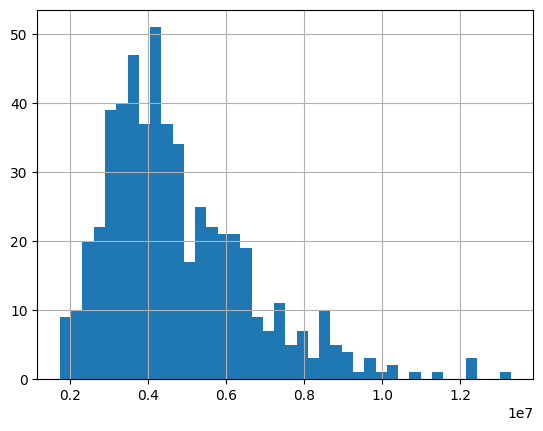

In [4]:
housing_data["price"].hist(bins=40)

<Axes: >

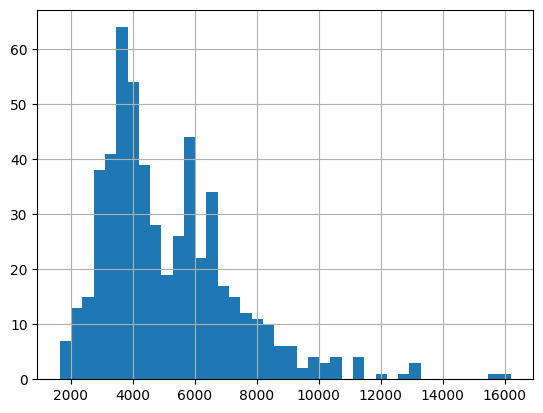

In [5]:
housing_data["area"].hist(bins=40)

<Axes: >

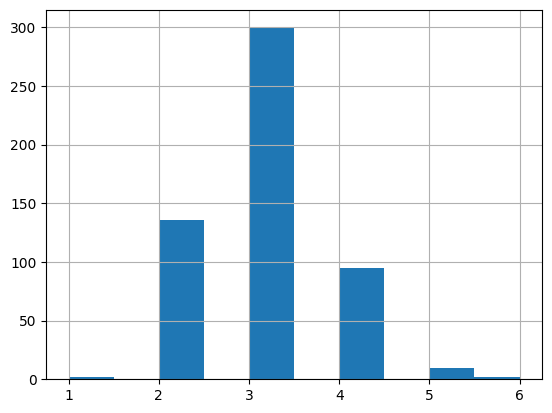

In [6]:
housing_data["bedrooms"].hist()

<Axes: >

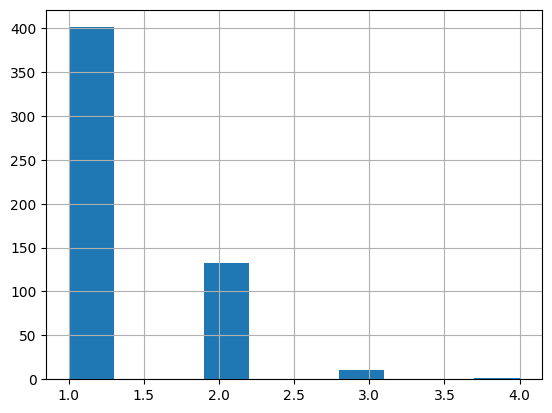

In [7]:
housing_data["bathrooms"].hist()

<Axes: >

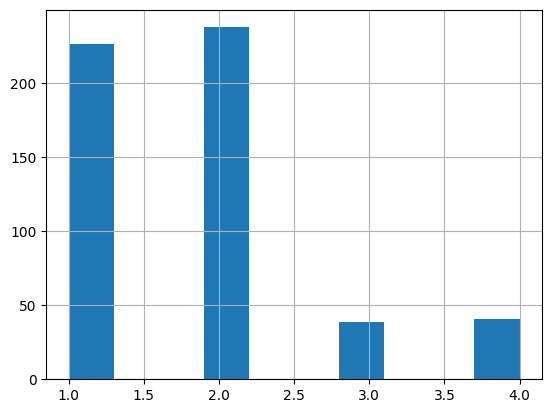

In [8]:
housing_data["stories"].hist()

<Axes: ylabel='count'>

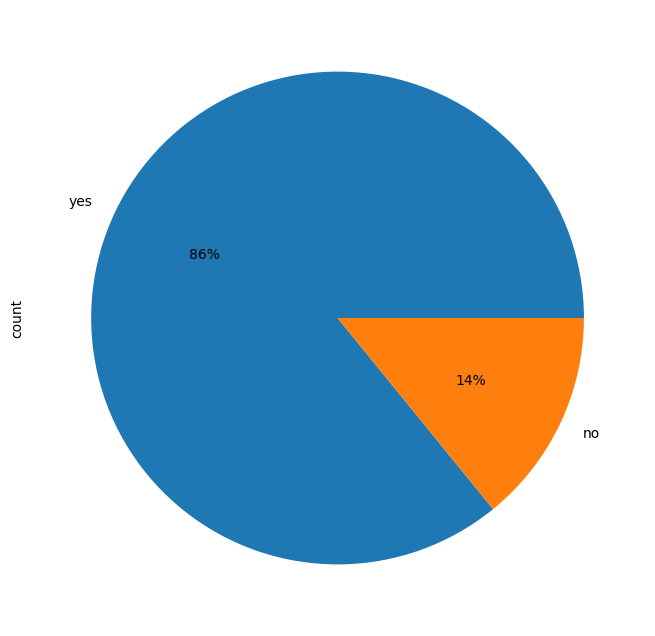

In [9]:
housing_data["mainroad"].value_counts().plot(kind="pie", figsize=(8, 8), autopct='%1.0f%%')

<Axes: ylabel='count'>

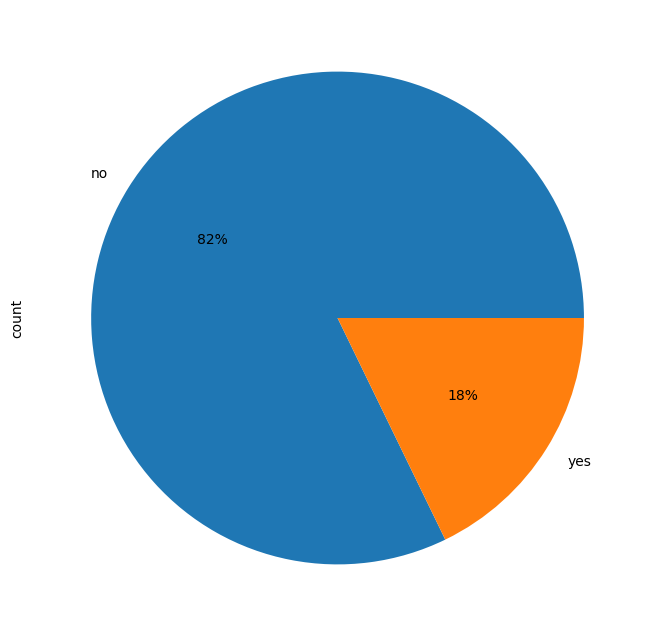

In [10]:
housing_data["guestroom"].value_counts().plot(kind="pie", figsize=(8, 8), autopct='%1.0f%%')

<Axes: ylabel='count'>

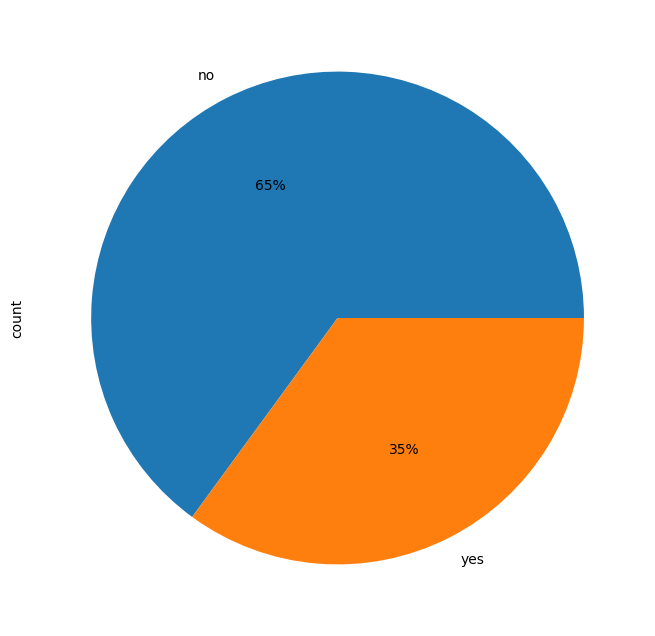

In [11]:
housing_data["basement"].value_counts().plot(kind="pie", figsize=(8, 8), autopct='%1.0f%%')

In [12]:
housing_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [13]:
import numpy as np

housing_data["price_cat"] = pd.cut(
    housing_data["price"],
    bins=[0, 3_430_000, 4_340_000, 5_740_000, np.inf],
    labels=[1, 2, 3, 4]
)
housing_data["price_cat"].value_counts()


,count
price_cat,
2,138
1,137
4,136
3,134


<Axes: >

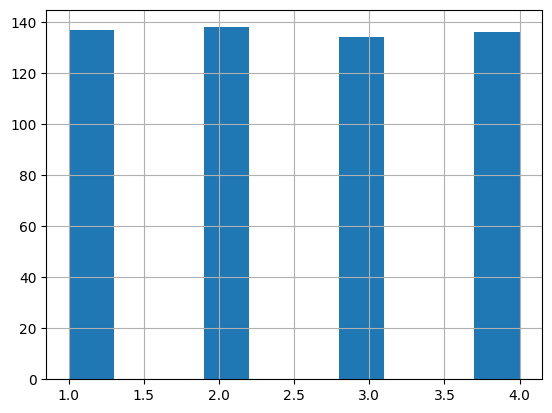

In [14]:
housing_data["price_cat"].hist()

# Split DataSet

In [15]:
y = housing_data["price"]
X = housing_data.drop("price", axis=1)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_cat
367,3630,2,1,1,yes,no,no,no,yes,0,no,unfurnished,2
151,4400,4,1,2,yes,no,no,no,yes,2,yes,semi-furnished,3
432,6060,3,1,1,yes,yes,yes,no,no,0,no,furnished,1
476,5850,3,1,2,yes,no,yes,no,no,1,no,unfurnished,1
539,2990,2,1,1,no,no,no,no,no,1,no,unfurnished,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,6000,3,2,2,yes,yes,no,no,no,1,no,semi-furnished,4
398,3120,3,1,2,yes,no,no,no,no,1,no,unfurnished,2
427,2145,3,1,2,yes,no,yes,no,no,0,yes,furnished,1
529,3970,3,1,2,yes,no,yes,no,no,0,no,unfurnished,1


<Axes: >

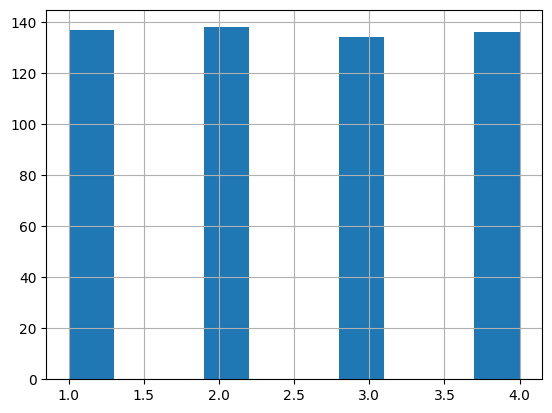

In [17]:
housing_data["price_cat"].hist()

# Stratified Split

In [18]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_data, housing_data["price_cat"]):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

In [19]:
strat_train_set

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_cat
43,7700000,6000,4,2,4,yes,no,no,no,no,2,no,semi-furnished,4
218,4830000,4815,2,1,1,yes,no,no,no,yes,0,yes,semi-furnished,3
40,7875000,6550,3,1,2,yes,no,yes,no,yes,0,yes,furnished,4
336,3920000,8080,3,1,1,yes,no,no,no,yes,2,no,semi-furnished,2
98,6293000,6600,3,2,3,yes,no,no,no,yes,0,yes,unfurnished,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,4403000,2880,3,1,2,yes,no,no,no,no,0,yes,semi-furnished,3
178,5229000,7085,3,1,1,yes,yes,yes,no,no,2,yes,semi-furnished,3
27,8400000,8875,3,1,1,yes,no,no,no,no,1,no,semi-furnished,4
142,5600000,10500,4,2,2,yes,no,no,no,no,1,no,semi-furnished,3


In [20]:
strat_test_set["price_cat"].value_counts() / len(strat_test_set)

,count
price_cat,
2,0.256881
1,0.247706
3,0.247706
4,0.247706


In [21]:
housing_data["price_cat"].value_counts() / len(housing_data)

,count
price_cat,
2,0.253211
1,0.251376
4,0.249541
3,0.245872


In [22]:

def income_cat_proportions(data):
    return data["price_cat"].value_counts() / len(data)
train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing_data),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand, %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat, %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

compare_props

,Overall,Stratified,Random,"Rand, %error","Strat, %error"
price_cat,,,,,
1,0.251376,0.247706,0.293578,16.788321,-1.459854
2,0.253211,0.256881,0.174312,-31.159420,1.449275
3,0.245872,0.247706,0.220183,-10.447761,0.746269
4,0.249541,0.247706,0.311927,25.000000,-0.735294


In [23]:
strat_train_set.drop("price_cat", axis="columns", inplace=True)
strat_test_set.drop("price_cat", axis="columns", inplace=True)

## VIsualizing Our Data

In [24]:
housing = strat_train_set.copy()

# Histograms

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

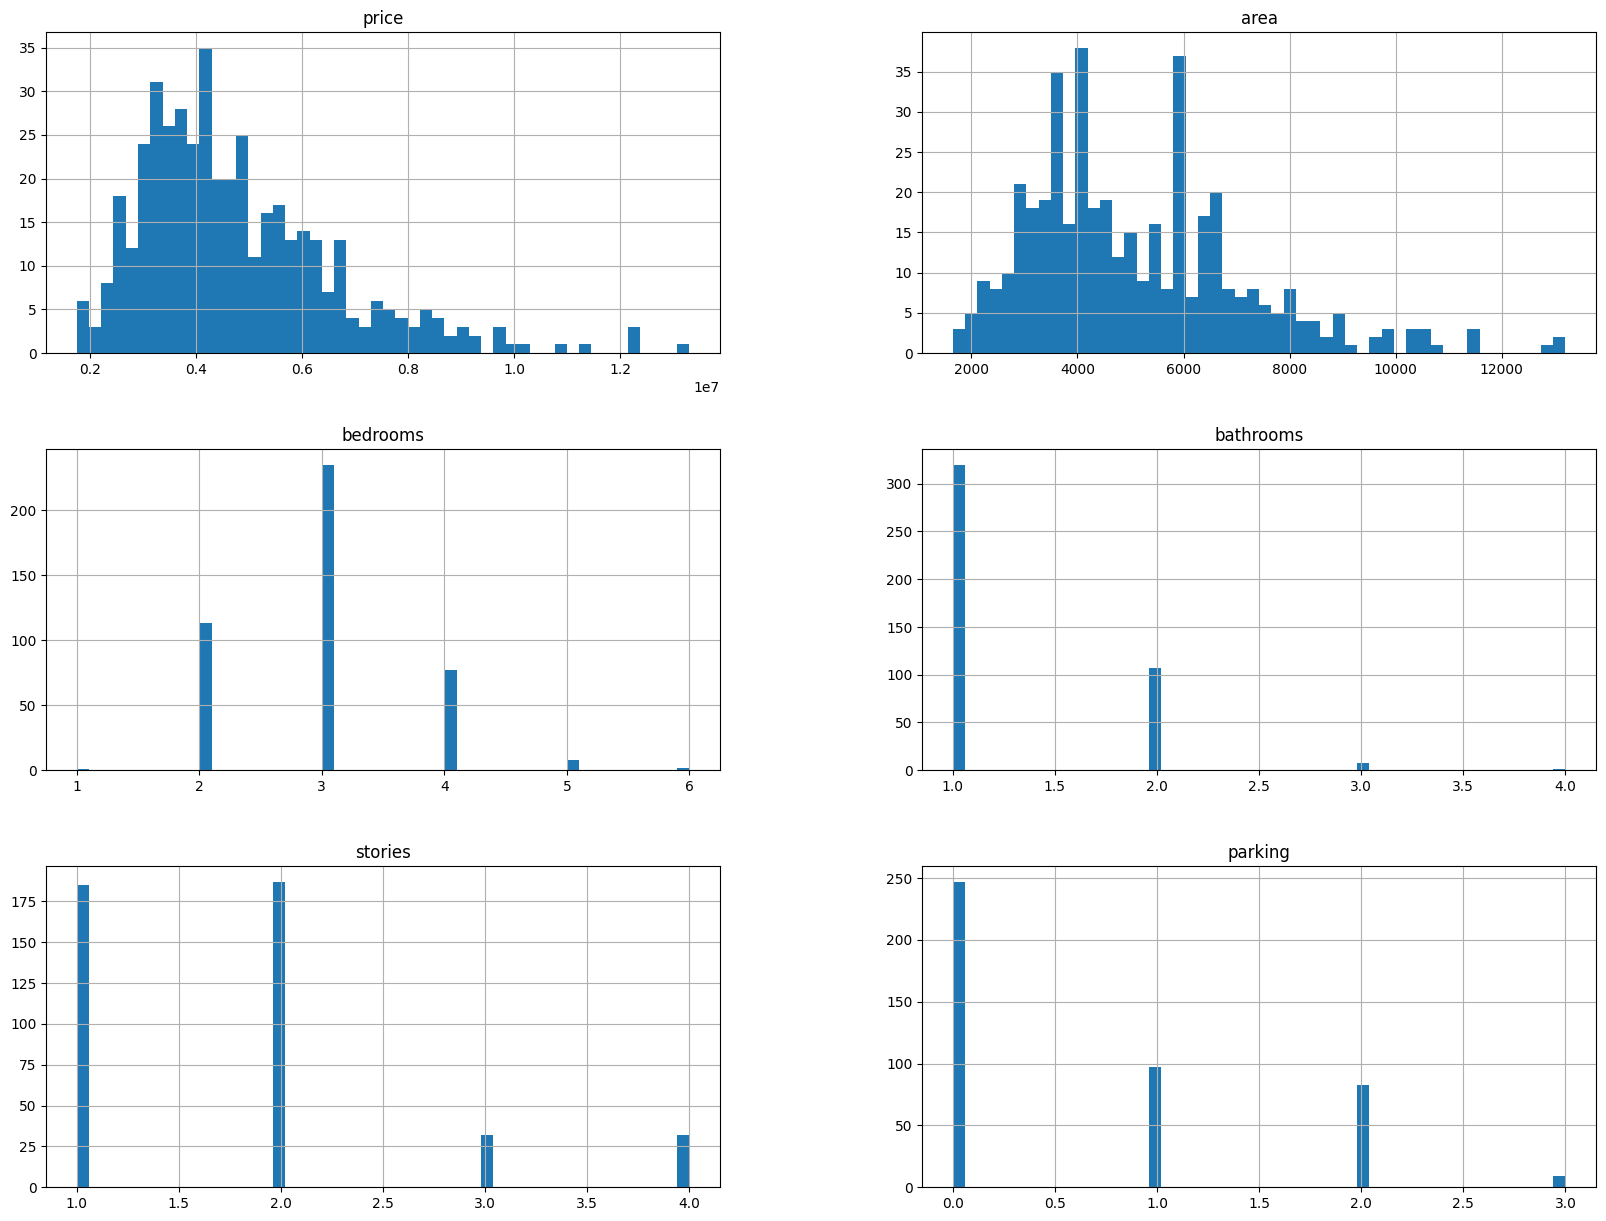

In [25]:
housing.hist(bins=50, figsize=(20,15))

In [26]:
housing.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.525371,0.406884,0.501777,0.429730,0.409982
area,0.525371,1.000000,0.150101,0.165978,0.085135,0.369282
bedrooms,0.406884,0.150101,1.000000,0.404251,0.410323,0.182279
bathrooms,0.501777,0.165978,0.404251,1.000000,0.333662,0.171137
stories,0.429730,0.085135,0.410323,0.333662,1.000000,0.037887
parking,0.409982,0.369282,0.182279,0.171137,0.037887,1.000000


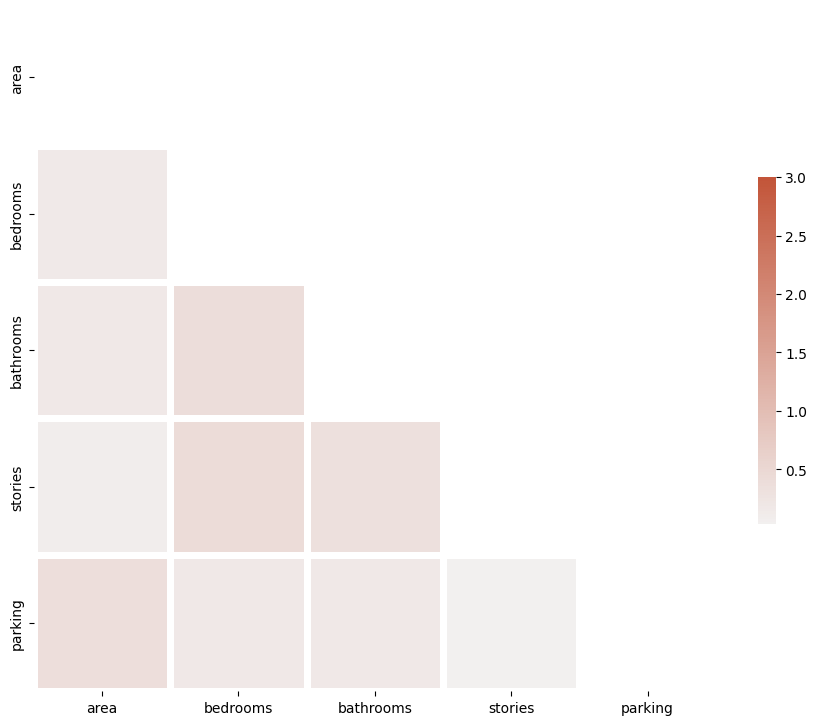

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = housing.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=3, center=0,
            square=True, linewidths=5, cbar_kws={"shrink": .5})
plt.show()

## Preparing Data for Machine Learning

In [40]:
housing = strat_train_set.drop("price", axis=1)

housing_labels = strat_train_set["price"].copy()

In [41]:
train_labels = strat_test_set.drop("price", axis=1)
test_labels = strat_test_set["price"].copy()

### Dealing with Missing Values

In [42]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


## Encode Categoties Variables

In [43]:
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_cat
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,4
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,4
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,4
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,4
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,1
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,1
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,1
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,1


In [44]:
housing_cat = housing[["mainroad", "guestroom", "basement", "hotwaterheating","airconditioning", "prefarea", "furnishingstatus" ]]
housing_cat.head(10)

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
43,yes,no,no,no,no,no,semi-furnished
218,yes,no,no,no,yes,yes,semi-furnished
40,yes,no,yes,no,yes,yes,furnished
336,yes,no,no,no,yes,no,semi-furnished
98,yes,no,no,no,yes,yes,unfurnished
227,yes,no,yes,no,yes,no,furnished
355,yes,no,no,no,no,no,furnished
104,yes,yes,yes,no,no,yes,furnished
518,yes,yes,no,no,no,no,unfurnished
28,yes,no,yes,yes,no,no,unfurnished


In [45]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1., 1., 1.],
       [1., 0., 1., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1., 1., 2.],
       [1., 0., 1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 1., 0.],
       [1., 1., 0., 0., 0., 0., 2.],
       [1., 0., 1., 1., 0., 0., 2.]])

In [46]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat_1hot # Creates a "dense array" meaning that all instances have a value
# not just the ones that are encoded

array([[0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 1., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 0., 1.]])

## Feature Engineering

In [47]:
def feature_engineering(data):
    data["area_per_story"] = data["area"] / data["stories"]
    data["bedrooms_per_story"] = data["bedrooms"] / data["stories"]
    data["bedrooms_per_area"] = data["bedrooms"] / data["area"]
    return data

In [48]:
housing["stories"]

,stories
43,4
218,1
40,2
336,1
98,3
...,...
265,2
178,1
27,1
142,2


In [49]:
housing_num = housing.select_dtypes(include=[np.number])
housing_num

,area,bedrooms,bathrooms,stories,parking
43,6000,4,2,4,2
218,4815,2,1,1,0
40,6550,3,1,2,0
336,8080,3,1,1,2
98,6600,3,2,3,0
...,...,...,...,...,...
265,2880,3,1,2,0
178,7085,3,1,1,2
27,8875,3,1,1,1
142,10500,4,2,2,1


In [50]:
housing_feature_engineered = feature_engineering(housing_num)
housing_feature_engineered

,area,bedrooms,bathrooms,stories,parking,area_per_story,bedrooms_per_story,bedrooms_per_area
43,6000,4,2,4,2,1500.0,1.0,0.000667
218,4815,2,1,1,0,4815.0,2.0,0.000415
40,6550,3,1,2,0,3275.0,1.5,0.000458
336,8080,3,1,1,2,8080.0,3.0,0.000371
98,6600,3,2,3,0,2200.0,1.0,0.000455
...,...,...,...,...,...,...,...,...
265,2880,3,1,2,0,1440.0,1.5,0.001042
178,7085,3,1,1,2,7085.0,3.0,0.000423
27,8875,3,1,1,1,8875.0,3.0,0.000338
142,10500,4,2,2,1,5250.0,2.0,0.000381


## Scaling Our Data

In [51]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

housing_scaled = scalar.fit_transform(housing_feature_engineered)
housing_scaled

array([[ 4.32558215e-01,  1.38746950e+00,  1.40543688e+00, ...,
        -9.13550019e-01, -1.23622718e+00,  2.31340494e-03],
       [-1.46268381e-01, -1.28924157e+00, -5.71242086e-01, ...,
         6.10399511e-01,  1.11260446e-01, -8.02418330e-01],
       [ 7.01211909e-01,  4.91139646e-02, -5.71242086e-01, ...,
        -9.75589434e-02, -5.62483367e-01, -6.65851024e-01],
       ...,
       [ 1.83688434e+00,  4.91139646e-02, -5.71242086e-01, ...,
         2.47683544e+00,  1.45874807e+00, -1.05008574e+00],
       [ 2.63063390e+00,  1.38746950e+00,  1.40543688e+00, ...,
         8.10374789e-01,  1.11260446e-01, -9.12629524e-01],
       [-3.00133678e-01,  4.91139646e-02, -5.71242086e-01, ...,
        -5.68765058e-01, -5.62483367e-01,  2.31340494e-03]])

## Pipeline

In [52]:
housing = strat_train_set.drop("price", axis=1)

housing_labels = strat_train_set["price"].copy()

def data_transformations(data):

    ### Separate labels if they Exist ###

    if "price" in data.columns:
        labels = data["price"]
        data = data.drop(["price"], axis=1)

    else:
        labels = None

    ### Feature Engineering ###
    feature_engineered_data = feature_engineering(data)
    features = list(feature_engineered_data.columns)
    # Creating a list of our features foer future use

    ### Imputing Data ###
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy="median")

    housing_num = feature_engineered_data.select_dtypes(include = [np.number])
    imputed = imputer.fit_transform(housing_num)

    ### Encoding Categorical Data ###
    housing_cat = feature_engineered_data.select_dtypes(exclude=[np.number])

    from sklearn.preprocessing import OneHotEncoder

    cat_encoder = OneHotEncoder(sparse_output=False)
    housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

    # Build readable, non-duplicate category names (column_value format)
    all_cat_names = []
    for col, cats in zip(housing_cat.columns, cat_encoder.categories_):
      for cat in cats:
        all_cat_names.append(f"{col}_{cat}")

    features = features + all_cat_names

# Remove the original categorical column names (not their one-hot outputs)
    categorical_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]
    features = [col for col in features if col not in categorical_cols]
    # We're encoding this variable, so we don't need it in our list anymore

    ### Scaling Numerical Data ###
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()

    housing_scaled = scaler.fit_transform(imputed)

        ### Concatening all Data ###
    output = np.hstack([housing_scaled, housing_cat_1hot])

    return output, labels, features

# Select and Train Model

In [53]:
train_data, train_labels, features = data_transformations(strat_train_set)
train_data

array([[ 0.43255822,  1.3874695 ,  1.40543688, ...,  0.        ,
         1.        ,  0.        ],
       [-0.14626838, -1.28924157, -0.57124209, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.70121191,  0.04911396, -0.57124209, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 1.83688434,  0.04911396, -0.57124209, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.6306339 ,  1.3874695 ,  1.40543688, ...,  0.        ,
         1.        ,  0.        ],
       [-0.30013368,  0.04911396, -0.57124209, ...,  0.        ,
         0.        ,  1.        ]])

In [54]:
features

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'area_per_story',
 'bedrooms_per_story',
 'bedrooms_per_area',
 'mainroad_no',
 'mainroad_yes',
 'guestroom_no',
 'guestroom_yes',
 'basement_no',
 'basement_yes',
 'hotwaterheating_no',
 'hotwaterheating_yes',
 'airconditioning_no',
 'airconditioning_yes',
 'prefarea_no',
 'prefarea_yes',
 'furnishingstatus_furnished',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [55]:
test_data, test_labels, features = data_transformations(strat_test_set)
test_data

array([[-0.78382575, -1.39570373, -0.56634024, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.62293747,  0.03950105, -0.56634024, ...,  0.        ,
         0.        ,  1.        ],
       [ 2.62253926,  1.47470583,  1.49136263, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.81624527,  0.03950105, -0.56634024, ...,  0.        ,
         1.        ,  0.        ],
       [-0.96290499,  0.03950105, -0.56634024, ...,  0.        ,
         0.        ,  1.        ],
       [-0.88571566,  1.47470583, -0.56634024, ...,  0.        ,
         0.        ,  1.        ]])

## Linear Regression

In [56]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(train_data, train_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
# Compare against some Test Data

original_values = test_labels[:5]

predicted_values = lin_reg.predict(test_data[:5])

comparison_dataframe = pd.DataFrame(data={"Original Values": original_values,
"Predicted Values": predicted_values})

comparison_dataframe["Differences"] = comparison_dataframe["Original Values"] - comparison_dataframe["Predicted Values"]

comparison_dataframe




,Original Values,Predicted Values,Differences
524,2380000,2.534306e+06,-1.543062e+05
401,3500000,6.015059e+06,-2.515059e+06
69,6790000,7.684260e+06,-8.942597e+05
266,4403000,4.512855e+06,-1.098550e+05
159,5460000,5.400998e+06,5.900193e+04


In [58]:
from sklearn.metrics import mean_squared_error

lin_mse = mean_squared_error(original_values, predicted_values)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(1197044.7637012359)

In [59]:
# Bring in the Metrics
from sklearn.metrics import mean_absolute_error
lin_mae = mean_absolute_error(original_values, predicted_values)
lin_mae

746496.3293324516

## Decision Tree Regressor

In [60]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg.fit(train_data, train_labels)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [61]:
train_prediction = tree_reg.predict(train_data)
tree_mse = mean_squared_error(train_labels, train_prediction)
tree_rmse = np.sqrt(tree_mse)
tree_rmse


np.float64(48607.94994818376)

### Cross-Validation

In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, train_data, train_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [63]:
def display_scores(scores):
  print("Scores:", scores)
  print("Mean:", scores.mean())
  print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [1996029.15041794 1594542.22199579 1691824.33386204 1399066.82066768
 1216600.52175949 1481048.53635708 2271903.36655782 1591200.67208294
 1931510.16498538 2033054.95340055]
Mean: 1720678.0742086717
Standard deviation: 311473.0333680532


## Random FOrest

In [64]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=50,
                                   random_state=42)
forest_reg.fit(train_data, train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [65]:
train_predictions = forest_reg.predict(train_data)
forest_mse = mean_squared_error(train_labels, train_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(450348.5194600979)

In [66]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, train_data,
                                train_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()


,0
count,1.000000e+01
mean,1.720678e+06
std,3.283214e+05
min,1.216601e+06
25%,1.508587e+06
50%,1.643183e+06
75%,1.979899e+06
max,2.271903e+06


## Fine-Tuning the Model

#### After you pick a model or set of models that are promising. You'll need to fine-tune the hyperparameters (parameters of model that aren't affected by training) in order to find the best ones to use for your model. You can use something called Grid Search in order to accomplish this

In [67]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3x4) combinations of hyperparameters
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    # then try 6 (2x3) combination with bootstrap set as False
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]},

]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)x5=90 rounds of training
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True)
grid_search.fit(train_data, train_labels)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [68]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [69]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [70]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
  print(np.sqrt(-mean_score), params)

1349868.3592224382 {'max_features': 2, 'n_estimators': 3}
1211522.9199757727 {'max_features': 2, 'n_estimators': 10}
1181923.4137500918 {'max_features': 2, 'n_estimators': 30}
1280701.7200373875 {'max_features': 4, 'n_estimators': 3}
1128263.77126204 {'max_features': 4, 'n_estimators': 10}
1104990.009829671 {'max_features': 4, 'n_estimators': 30}
1351710.5352822805 {'max_features': 6, 'n_estimators': 3}
1222497.8398652754 {'max_features': 6, 'n_estimators': 10}
1151885.2652346299 {'max_features': 6, 'n_estimators': 30}
1233726.0432802434 {'max_features': 8, 'n_estimators': 3}
1144265.1908918323 {'max_features': 8, 'n_estimators': 10}
1134734.0404409026 {'max_features': 8, 'n_estimators': 30}
1324713.8548745266 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
1215461.5064341575 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
1332577.4122903768 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
1187492.7784295217 {'bootstrap': False, 'max_features': 3, 'n_es

In [71]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.007233,0.001792,0.001540,0.000329,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-1.238823e+12,-1.714162e+12,...,-1.822145e+12,3.341656e+11,17,-5.254178e+11,-4.310752e+11,-5.715191e+11,-5.271782e+11,-5.149869e+11,-5.140354e+11,4.580385e+10
1,0.015807,0.000467,0.002116,0.000062,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-1.134681e+12,-1.392499e+12,...,-1.467788e+12,2.122270e+11,9,-3.142770e+11,-2.896937e+11,-3.297128e+11,-3.722032e+11,-2.854824e+11,-3.182738e+11,3.145572e+10
2,0.044823,0.001769,0.004064,0.000181,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-1.148469e+12,-1.371678e+12,...,-1.396943e+12,1.676035e+11,7,-2.136790e+11,-2.218388e+11,-2.279538e+11,-2.268626e+11,-2.087588e+11,-2.198186e+11,7.481927e+09
3,0.006088,0.000171,0.001336,0.000057,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-1.312338e+12,-1.829227e+12,...,-1.640197e+12,1.800195e+11,13,-4.064438e+11,-5.007892e+11,-4.935281e+11,-3.975497e+11,-4.780481e+11,-4.552718e+11,4.420441e+10
4,0.016596,0.000207,0.002087,0.000030,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-1.092795e+12,-1.431238e+12,...,-1.272979e+12,1.937629e+11,2,-2.941479e+11,-2.787936e+11,-2.876871e+11,-2.623116e+11,-2.568208e+11,-2.759522e+11,1.434535e+10
5,0.047866,0.000534,0.004042,0.000133,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-1.017833e+12,-1.290538e+12,...,-1.221003e+12,2.005673e+11,1,-2.132793e+11,-2.046328e+11,-2.206569e+11,-2.012075e+11,-1.760848e+11,-2.031723e+11,1.514983e+10
6,0.006776,0.000320,0.001435,0.000063,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-2.109253e+12,-1.520454e+12,...,-1.827121e+12,2.128379e+11,18,-6.292176e+11,-4.777051e+11,-4.514462e+11,-4.501713e+11,-5.766662e+11,-5.170413e+11,7.274657e+10
7,0.019974,0.003484,0.002569,0.000547,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-1.445468e+12,-1.448997e+12,...,-1.494501e+12,1.541992e+11,11,-3.065678e+11,-2.723956e+11,-3.172832e+11,-2.965708e+11,-3.062129e+11,-2.998061e+11,1.519223e+10
8,0.051290,0.001312,0.004040,0.000060,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-1.158053e+12,-1.324842e+12,...,-1.326840e+12,1.188021e+11,5,-1.984958e+11,-2.074082e+11,-2.241964e+11,-1.977062e+11,-1.949613e+11,-2.045536e+11,1.067318e+10
9,0.007119,0.000546,0.001447,0.000128,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-1.483550e+12,-1.772671e+12,...,-1.522080e+12,1.366820e+11,12,-4.750062e+11,-4.725900e+11,-4.814959e+11,-4.226893e+11,-5.307795e+11,-4.765122e+11,3.430551e+10


### Randomized Search

allow you to more easily find the hyperparameters that we're interested in because instead of searching through all possible combinations, It randomly picks a couple and tries those out

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "n_estimators": randint(low=1, high=201),
    "max_features": randint(low=1, high=9),
}

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=11, cv=5, scoring="neg_mean_squared_error", random_state=42)
rnd_search.fit(train_data, train_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_features': <scipy.stats....x7955f376c980>, 'n_estimators': <scipy.stats....x7955f10f5970>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",11
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:

In [73]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
  print(np.sqrt(-mean_score), params)

1349868.3592224382 {'max_features': 2, 'n_estimators': 3}
1211522.9199757727 {'max_features': 2, 'n_estimators': 10}
1181923.4137500918 {'max_features': 2, 'n_estimators': 30}
1280701.7200373875 {'max_features': 4, 'n_estimators': 3}
1128263.77126204 {'max_features': 4, 'n_estimators': 10}
1104990.009829671 {'max_features': 4, 'n_estimators': 30}
1351710.5352822805 {'max_features': 6, 'n_estimators': 3}
1222497.8398652754 {'max_features': 6, 'n_estimators': 10}
1151885.2652346299 {'max_features': 6, 'n_estimators': 30}
1233726.0432802434 {'max_features': 8, 'n_estimators': 3}
1144265.1908918323 {'max_features': 8, 'n_estimators': 10}
1134734.0404409026 {'max_features': 8, 'n_estimators': 30}
1324713.8548745266 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
1215461.5064341575 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
1332577.4122903768 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
1187492.7784295217 {'bootstrap': False, 'max_features': 3, 'n_es

In [74]:
feature_importance = grid_search.best_estimator_.feature_importances_
feature_importance

array([0.19070527, 0.06942442, 0.1053962 , 0.06068303, 0.06446929,
       0.072084  , 0.03311959, 0.09139025, 0.01077673, 0.01778994,
       0.01056218, 0.01351434, 0.01692213, 0.01679016, 0.01645462,
       0.01524113, 0.05157735, 0.04832984, 0.02689931, 0.02035437,
       0.01404911, 0.01448157, 0.01898519])

## Feature Importance List
Judging the importance of various features is very important at this allows us to explain to our stakeholders which feature is most important and why which is becoming more important as more advanced models behave like blackboxes

In [75]:
feature_importance_list = list(zip(features, feature_importance.tolist()))
feature_importance_list

[('area', 0.19070527278641555),
 ('bedrooms', 0.06942442036154353),
 ('bathrooms', 0.10539619843043817),
 ('stories', 0.06068302510416202),
 ('parking', 0.06446928925504812),
 ('area_per_story', 0.0720839953969523),
 ('bedrooms_per_story', 0.03311959011581452),
 ('bedrooms_per_area', 0.09139024724073248),
 ('mainroad_no', 0.010776727571457693),
 ('mainroad_yes', 0.017789944744326776),
 ('guestroom_no', 0.010562175516568567),
 ('guestroom_yes', 0.01351433623914672),
 ('basement_no', 0.01692213441332072),
 ('basement_yes', 0.01679015655496306),
 ('hotwaterheating_no', 0.016454620628881717),
 ('hotwaterheating_yes', 0.015241129161757936),
 ('airconditioning_no', 0.05157734606204622),
 ('airconditioning_yes', 0.04832983729098495),
 ('prefarea_no', 0.026899308222401004),
 ('prefarea_yes', 0.020354367911781527),
 ('furnishingstatus_furnished', 0.014049107731969369),
 ('furnishingstatus_semi-furnished', 0.014481574448330715),
 ('furnishingstatus_unfurnished', 0.018985194810956098)]

<BarContainer object of 23 artists>

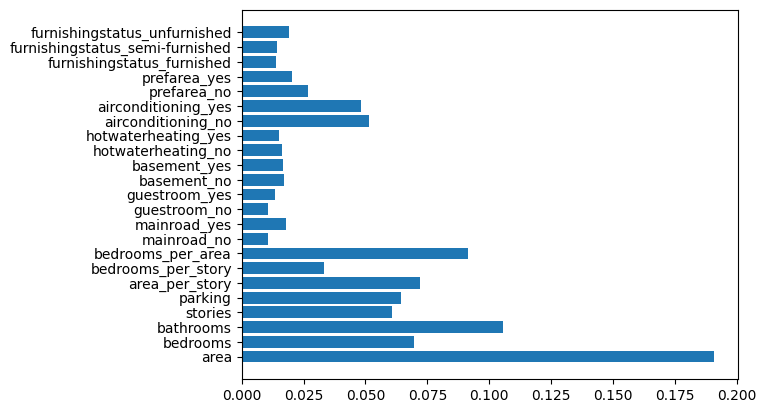

In [76]:
plt.barh(y=features, width=feature_importance.tolist())

In [77]:
final_model = grid_search.best_estimator_

final_predictions = final_model.predict(test_data)

final_mse = mean_squared_error(test_labels, final_predictions)
final_rmse = np.sqrt(final_mse)

In [78]:
final_rmse

np.float64(1107604.6329520917)

In [79]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - test_labels) ** 2
stats.t.interval(confidence, len(squared_errors) - 1,
                 loc = squared_errors.mean(),
                 scale = stats.sem(squared_errors))


(np.float64(799505118123.1135), np.float64(1654070927750.7625))

### Step 1: Wrap feature_engineering in FunctionTransformer

In [80]:
from sklearn.preprocessing import FunctionTransformer

feature_engineering_transformer = FunctionTransformer(feature_engineering)

### Step 2: Build numeric and categorical pipelines separately

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("cat_encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

### Step 3: Combine numeric and categorical handling with ColumnTransformer

In [82]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_cat
367,3630,2,1,1,yes,no,no,no,yes,0,no,unfurnished,2
151,4400,4,1,2,yes,no,no,no,yes,2,yes,semi-furnished,3
432,6060,3,1,1,yes,yes,yes,no,no,0,no,furnished,1
476,5850,3,1,2,yes,no,yes,no,no,1,no,unfurnished,1
539,2990,2,1,1,no,no,no,no,no,1,no,unfurnished,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,6000,3,2,2,yes,yes,no,no,no,1,no,semi-furnished,4
398,3120,3,1,2,yes,no,no,no,no,1,no,unfurnished,2
427,2145,3,1,2,yes,no,yes,no,no,0,yes,furnished,1
529,3970,3,1,2,yes,no,yes,no,no,0,no,unfurnished,1


In [84]:
from sklearn.compose import ColumnTransformer

num_attribs = ["stories", "parking","area_per_story", "bedrooms_per_area","bedrooms_per_story"]
cat_attribs = ["mainroad",	"guestroom",	"basement",	"hotwaterheating", 	"airconditioning", "prefarea",	"furnishingstatus"]

preprocessing = ColumnTransformer([
    ("num", numeric_pipeline, num_attribs),
    ("cat", categorical_pipeline, cat_attribs),
])
from sklearn.compose import ColumnTransformer

num_attribs = ["stories", "parking","area_per_story", "bedrooms_per_area","bedrooms_per_story"]
cat_attribs = ["mainroad",	"guestroom",	"basement",	"hotwaterheating", 	"airconditioning", "prefarea",	"furnishingstatus"]

preprocessing = ColumnTransformer([
    ("num", numeric_pipeline, num_attribs),
    ("cat", categorical_pipeline, cat_attribs),
])


Step 4: Chain feature engineering and preprocessing together

In [85]:
full_preprocessing = Pipeline([
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessing", preprocessing)
])

### Step 5: Now attach your trained model

In [86]:
full_pipeline_with_predictor = Pipeline([
    ("full_preprocessing", full_preprocessing),
    ("random_forest", final_model)
])

### Step 6: Fit on raw data — housing, not the transformed output

In [87]:
full_pipeline_with_predictor.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('full_preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...x7955f1163740>
,"inverse_func inverse_func: callable, default=NoneThe callab

In [88]:
import numpy as np
from sklearn.metrics import mean_squared_error

X_train_raw = strat_train_set.drop("price", axis=1)
y_train = strat_train_set["price"].copy()

X_test_raw = strat_test_set.drop("price", axis=1)
y_test = strat_test_set["price"].copy()

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)

new_predictions = full_pipeline_with_predictor.predict(X_test_raw)
new_rmse = np.sqrt(mean_squared_error(y_test, new_predictions))

# COMPARE
# print("\nOriginal RMSE (data_transformations, has leakage):", original_rmse)
print("New pipeline RMSE (full_pipeline_with_predictor):", new_rmse)

X_train_raw shape: (436, 12)
X_test_raw shape: (109, 12)
New pipeline RMSE (full_pipeline_with_predictor): 1366079.1178165157


In [89]:

import numpy as np
import joblib
from sklearn.metrics import mean_squared_error

# Generate predictions on the test set using the full pipeline
check_predictions = full_pipeline_with_predictor.predict(X_test_raw)

# The real check: is the RMSE reasonable? (Not whether it matches the old leaky model)
new_rmse = np.sqrt(mean_squared_error(y_test, check_predictions))
print("New pipeline RMSE:", new_rmse)

# Save the complete pipeline (feature engineering + preprocessing + model)
joblib.dump(full_pipeline_with_predictor, "housing_model.pkl")
print("Model saved successfully.")

New pipeline RMSE: 1366079.1178165157
Model saved successfully.
